# Exploratory Data Analysis - Claims Data
Source: https://www.kaggle.com/datasets/bonifacechosen/nhis-healthcare-claims-and-fraud-dataset/versions/1

In [1]:
#Loading the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Loading the Data
df = pd.read_csv("claims.csv")
df.head()

,Patient ID,Age,Gender,Date Admitted,Date Discharged,Diagnosis,Treatment,Amount Billed,Fraud Type
0,9b484756-3a0d-47f4-ada3-fb63ed2d1082,82,Male,2023-02-06,2023-02-06,Appendectomy,Appendectomy,144764.37,No Fraud
1,0240f93e-8c46-4c2a-a4cb-827ecf527d36,29,Male,2022-09-03,2022-09-04,Cesarean Section,Fake Cesarean Section,531434.03,Fake Treatment
2,0e0e0476-cf0f-4b87-828c-a34bdd780e68,70,Male,2022-10-02,2022-10-17,Advanced Spinal Surgery,Phantom Procedure,128604.41,Phantom Billing
3,ad669adf-568d-4346-b60e-a26a3374f00d,12,Male,2023-11-15,2023-11-20,Peptic Ulcer,Peptic Ulcer,304989.18,No Fraud
4,9c0cc9c5-ff6f-442b-9c25-60ad3f1a4400,72,Male,2022-11-15,2022-12-04,Appendectomy,Appendectomy,277021.33,No Fraud


## **Dataset Overview**

In [3]:
print("Rows, Columns:", df.shape)
print("")
print("Columns:", df.columns.tolist())
print("")
print("Data information:\n", df.info())
print("")
print("Number of Unique Values per column:\n")
print(df.nunique())

Rows, Columns: (1500, 9)

Columns: ['Patient ID', 'Age', 'Gender', 'Date Admitted', 'Date Discharged', 'Diagnosis', 'Treatment', 'Amount Billed', 'Fraud Type']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Patient ID       1500 non-null   object 
 1   Age              1500 non-null   int64  
 2   Gender           1500 non-null   object 
 3   Date Admitted    1500 non-null   object 
 4   Date Discharged  1500 non-null   object 
 5   Diagnosis        1500 non-null   object 
 6   Treatment        1500 non-null   object 
 7   Amount Billed    1500 non-null   float64
 8   Fraud Type       1500 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 105.6+ KB
Data information:
 None

Number of Unique Values per column:

Patient ID         1500
Age                 100
Gender                2
Date Admitted       642
Date 

- There are total 1500 rows (claims) and 9 columns (features).
- The datatype for Date Admitted and Date Discharged needs to be changed from object to datetime.

In [4]:
# Datatype conversion
df['Date Admitted'] = df['Date Admitted'].astype('datetime64[ns]')
df['Date Discharged'] = df['Date Discharged'].astype('datetime64[ns]')


In [5]:
# Datatype validation
expected_dtypes = {
    'Patient ID': 'object',
    'Age' : 'int64',
    'Gender': 'object',
    'Date Admitted': 'datetime64[ns]',
    'Date Discharged': 'datetime64[ns]',
    'Diagnosis' : 'object',
    'Treatment' : 'object',
    'Amout Billed' : 'float64',
    'Fraud Type' : 'object'
}

for col, expected in expected_dtypes.items():
  if col in df.columns:
    actual = df[col].dtype
    print("")
    print(f"{col}: actual = {actual}, expected = {expected}")



Patient ID: actual = object, expected = object

Age: actual = int64, expected = int64

Gender: actual = object, expected = object

Date Admitted: actual = datetime64[ns], expected = datetime64[ns]

Date Discharged: actual = datetime64[ns], expected = datetime64[ns]

Diagnosis: actual = object, expected = object

Treatment: actual = object, expected = object

Fraud Type: actual = object, expected = object


Datatypes successfully validated.



In [6]:
# Missing Value Analysis
df.isna().sum()

,0
Patient ID,0
Age,0
Gender,0
Date Admitted,0
Date Discharged,0
Diagnosis,0
Treatment,0
Amount Billed,0
Fraud Type,0


There are no missing values.

In [8]:
# Duplicated values
print("Number of Duplicated values:", df.duplicated().sum())

if df.duplicated().sum() == 0:
  print("No duplicated values found.")
else:
  print("Duplicated values found.")

Number of Duplicated values: 0
No duplicated values found.


In [9]:
# Features Addition
df['Length of Stay'] = (df['Date Discharged'] - df['Date Admitted']).dt.days
df['Cost per Day'] = df['Amount Billed'] / df['Length of Stay']

df["Cost per Day"].replace([np.inf, -np.inf], np.nan, inplace=True)
df["Cost per Day"].fillna(0, inplace=True)

/tmp/ipykernel_1999/277406863.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Cost per Day"].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_1999/277406863.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [10]:
df.head()

,Patient ID,Age,Gender,Date Admitted,Date Discharged,Diagnosis,Treatment,Amount Billed,Fraud Type,Length of Stay,Cost per Day
0,9b484756-3a0d-47f4-ada3-fb63ed2d1082,82,Male,2023-02-06,2023-02-06,Appendectomy,Appendectomy,144764.37,No Fraud,0,0.000000
1,0240f93e-8c46-4c2a-a4cb-827ecf527d36,29,Male,2022-09-03,2022-09-04,Cesarean Section,Fake Cesarean Section,531434.03,Fake Treatment,1,531434.030000
2,0e0e0476-cf0f-4b87-828c-a34bdd780e68,70,Male,2022-10-02,2022-10-17,Advanced Spinal Surgery,Phantom Procedure,128604.41,Phantom Billing,15,8573.627333
3,ad669adf-568d-4346-b60e-a26a3374f00d,12,Male,2023-11-15,2023-11-20,Peptic Ulcer,Peptic Ulcer,304989.18,No Fraud,5,60997.836000
4,9c0cc9c5-ff6f-442b-9c25-60ad3f1a4400,72,Male,2022-11-15,2022-12-04,Appendectomy,Appendectomy,277021.33,No Fraud,19,14580.070000


Two new features: Length of Day and Cost per Day successfully added.

In [11]:
# Categorisation of columns into numerical and categorical
num_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
cat_cols = [col for col in df.columns if col not in num_cols]


print("Numerical Columns:", num_cols)
print("")
print("Categorical Columns:", cat_cols)

Numerical Columns: ['Age', 'Amount Billed', 'Length of Stay', 'Cost per Day']

Categorical Columns: ['Patient ID', 'Gender', 'Date Admitted', 'Date Discharged', 'Diagnosis', 'Treatment', 'Fraud Type']


## Univariate Analysis

#### Descriptive Statistics



In [12]:
print("Summary Statistics:\n")
print(df[num_cols].describe())

Summary Statistics:

               Age  Amount Billed  Length of Stay   Cost per Day
count  1500.000000    1500.000000     1500.000000    1500.000000
mean     51.524000  317656.620040        4.819333   84990.221151
std      28.673569  194620.708614        4.560763  122574.923296
min       1.000000   10766.520000        0.000000       0.000000
25%      27.750000  166130.780000        1.000000    9276.956813
50%      51.000000  299130.385000        3.000000   40814.133369
75%      76.000000  432317.790000        8.000000   98518.244500
max     100.000000  988886.730000       19.000000  877917.650000


In [13]:
print("Total Amount Billed:", df["Amount Billed"].sum())

Total Amount Billed: 476484930.06


In [14]:
print("Mean:")
print(df[num_cols].mean())

print("-"*50)

print("Median:")
print(df[num_cols].median())

print("-"*50)

print("Mode:")
print(df[num_cols].mode().iloc[0])

Mean:
Age                   51.524000
Amount Billed     317656.620040
Length of Stay         4.819333
Cost per Day       84990.221151
dtype: float64
--------------------------------------------------
Median:
Age                   51.000000
Amount Billed     299130.385000
Length of Stay         3.000000
Cost per Day       40814.133369
dtype: float64
--------------------------------------------------
Mode:
Age                  83.00
Amount Billed     10766.52
Length of Stay        0.00
Cost per Day          0.00
Name: 0, dtype: float64


In [15]:
print("Variance:")
print(df[num_cols].var())

print("-"*50)

print("Standard Deviation:")
print(df[num_cols].std())

print("-"*50)

print("\nSkewness:")
print(df[num_cols].skew())


Variance:
Age               8.221735e+02
Amount Billed     3.787722e+10
Length of Stay    2.080056e+01
Cost per Day      1.502461e+10
dtype: float64
--------------------------------------------------
Standard Deviation:
Age                   28.673569
Amount Billed     194620.708614
Length of Stay         4.560763
Cost per Day      122574.923296
dtype: float64
--------------------------------------------------

Skewness:
Age              -0.028163
Amount Billed     0.810832
Length of Stay    0.904843
Cost per Day      2.620004
dtype: float64


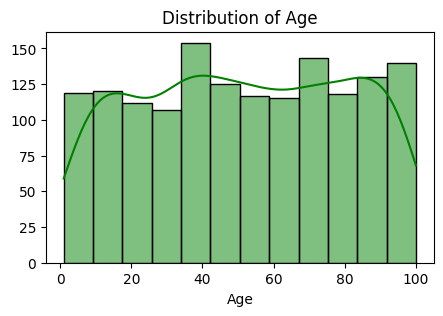

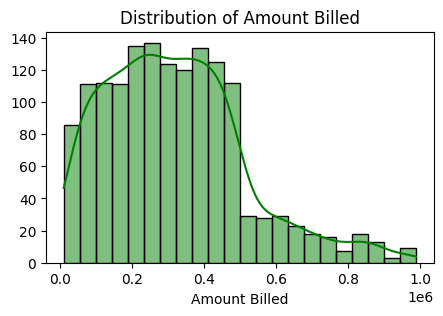

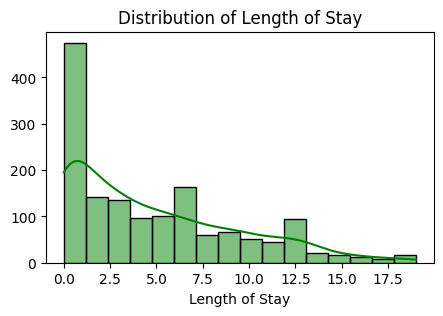

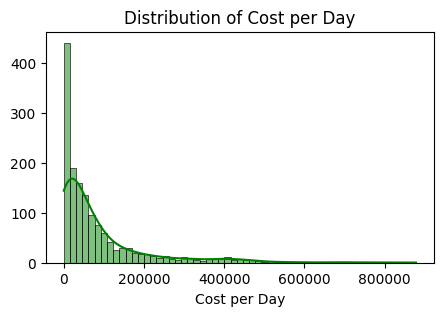

In [16]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True, color = "green")
    plt.title(f"Distribution of {col}")
    plt.ylabel("")
    plt.show()


### Univariate Analysis: Inferences

Age

- Mean and median are nearly equal (51.5 and 51), indicating a symmetric, uniform distribution across age groups.
- Age ranges from 1 to 100, suggesting claims span all life stages from pediatric to elderly.
- Slight negative skewness (-0.03) confirms near-perfect symmetry.

Amount Billed

- Mean (317,657) is higher than the median (299,130), indicating right skewness. A few very high-cost claims are pulling the average up.
- Wide standard deviation (194,621) reflects high billing variability across claim types.
- Positive skewness (0.81) and moderate kurtosis (0.65) confirm a right-tailed distribution with some extreme billing outliers.

Length of Stay

- Average stay is  about 4.8 days with a median of 3 days, suggesting most patients have short stays but a few outliers extend the mean.
- Positive skewness (0.90) confirms a right-tailed distribution. Most stays are brief with occasional long admissions.

Cost per Day

- Highly right-skewed (skewness = 2.62), meaning a small number of claims have extremely high daily costs.
- Mean (84,990) is more than double the median (40,814), driven by a few very expensive daily billings.
- Maximum of 877,918/day points to potential outlier cases or fraudulent inflation.

Distribution Plots

- Age follows a near-uniform distribution. Claims are evenly spread across all age groups, confirming no age-based sampling bias.
- Amount Billed is right-skewed and most claims fall in a moderate range, but a long right tail indicates high-cost procedures or fraud-inflated bills.
- Length of Stay is right-skewed and short stays dominate, but a tail of longer admissions exists, likely linked to complex or fraudulent cases.
- Cost per Day is the most skewed of all numerical features with the extreme right tail strongly suggesting the presence of fraudulent billing inflating daily costs artificially.



## Bivariate Analysis

/tmp/ipykernel_2268/509437980.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Gender'], y=df['Age'], palette="viridis")


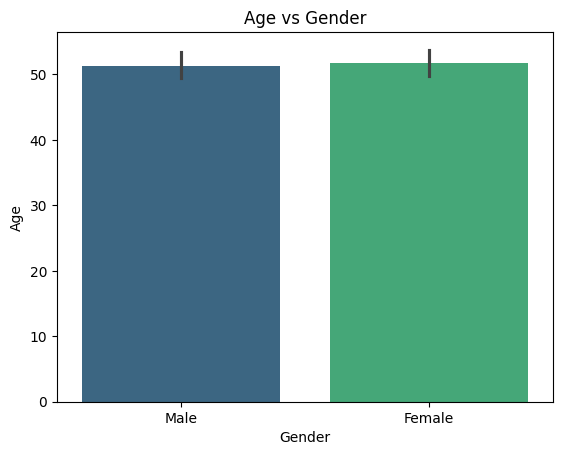

In [12]:
# Age vs Gender
plt.Figure(figsize=(5,3))
sns.barplot(x=df['Gender'], y=df['Age'], palette="viridis")
plt.title("Age vs Gender")
plt.show()

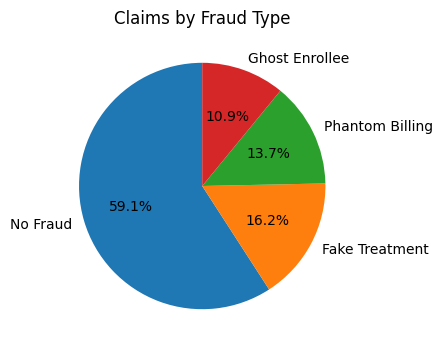

In [26]:
#Claims by Fraud Type

fraud_counts = df["Fraud Type"].value_counts()

plt.figure(figsize=(4,4))
plt.pie(
    fraud_counts,
    labels=fraud_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Claims by Fraud Type")
plt.show()

In [62]:
df['Fraud Type'].value_counts()

,count
Fraud Type,
No Fraud,887
Fake Treatment,243
Phantom Billing,206
Ghost Enrollee,164


### Fraud Type Analysis:  Inference

- No Fraud accounts for the majority of claims at 59.1% (887 claims).
Fake Treatment is the most common fraud type at 16.2% (243 claims), followed by Phantom Billing at 13.7% (206 claims) and Ghost Enrollee at 10.9% (164 claims).
- Combined, the three fraud categories account for 41% of all claims — a substantial fraud exposure rate.

In [18]:
#Numerical columns by Gender
df[num_cols + ["Gender"]].groupby("Gender").mean()

,Age,Amount Billed,Length of Stay,Cost per Day
Gender,,,,
Female,51.736842,324756.856248,4.823212,86893.901027
Male,51.316206,310724.768880,4.815547,83131.687833


### Gender vs Numerical Features: Inference

- There is negligible average age difference and is almost identical for Female (51.7) and Male (51.3). No age gap between genders in the claims data.
- Females show a slightly higher average amount billed (324,757 vs 310,725), though the difference is modest (about 4.5%).
- Cost per day is marginally higher for females (86,894 vs 83,132).
- Overall, gender shows no meaningful influence on billing behavior — fraud does not appear to be gender-concentrated.

### Outlier Detection

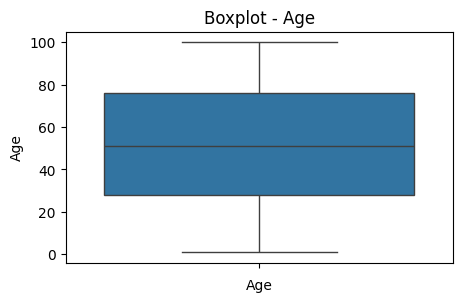

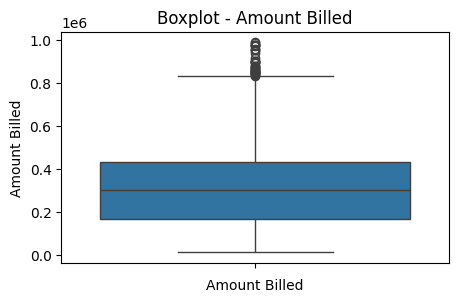

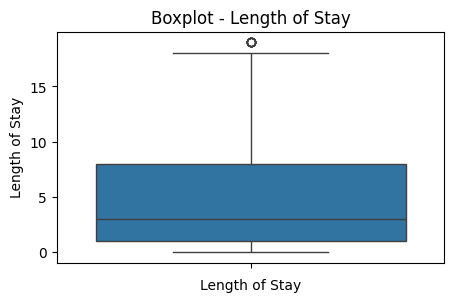

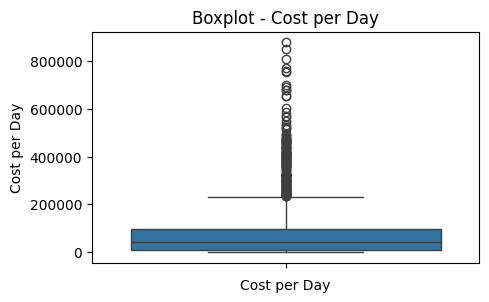

In [28]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

In [17]:
# Fraud vs Diagnosis
fraud_diag = pd.crosstab(df["Diagnosis"], df["Fraud Type"])

# Fraud vs Treatment
fraud_treat = pd.crosstab(df["Treatment"], df["Fraud Type"])

# Avg Cost in Fraud Cases
fraud_cost = df.groupby("Fraud Type")["Amount Billed"].mean()

In [18]:
#Number of claims by Fraud Type
df['Fraud Type'].value_counts()

,count
Fraud Type,
No Fraud,887
Fake Treatment,243
Phantom Billing,206
Ghost Enrollee,164


In [19]:
#Average Length of Stay by Fraud Type
print("Avg Length of Stay by Fraud Type\n")
df.groupby("Fraud Type")["Length of Stay"].mean()

Avg Length of Stay by Fraud Type



,Length of Stay
Fraud Type,
Fake Treatment,5.020576
Ghost Enrollee,4.317073
No Fraud,4.828636
Phantom Billing,4.941748


In [20]:
#Avg Cost per Day by Fraud Type
print("Avg Cost per Day by Fraud Type\n")
df.groupby("Fraud Type")["Cost per Day"].mean()

Avg Cost per Day by Fraud Type



,Cost per Day
Fraud Type,
Fake Treatment,94440.065763
Ghost Enrollee,73951.057868
No Fraud,69851.514244
Phantom Billing,147816.160783


In [21]:
#Top 10 High Cost Diagnosis
print("Top 10 High Cost Diagnosis:\n")
df.groupby("Diagnosis")["Amount Billed"].mean().sort_values(ascending=False).head(10)

Top 10 High Cost Diagnosis:



,Amount Billed
Diagnosis,
Epilepsy Surgery,625052.184783
Infertility Treatment (IVF),583118.363030
Cosmetic Surgery,581171.548148
Organ Transplant,579659.167826
Complex Heart Surgery,506539.412692
Neurosurgery,503446.875238
Cancer Treatment,491025.682333
Advanced Spinal Surgery,480536.627391
Cesarean Section,305776.758333


### Top 10 High-Cost Diagnoses

- Epilepsy Surgery (625,052), IVF (583,118), and Cosmetic Surgery (581,172) are the three most expensive diagnoses on average.
- Specialist and elective procedures dominate the high-cost list, which are also more susceptible to billing manipulation.
- These high-cost diagnosis categories warrant priority scrutiny in fraud audits given their elevated billing baseline.

In [22]:
#Top 10 Flagged Diagnosis
flagged = df[df["Fraud Type"] != "No Fraud"]

top_flagged_diag = (
    flagged["Diagnosis"]
    .value_counts()
    .head(10)
)

print("Top 10 Flagged Diagnosis:\n")
print(top_flagged_diag)

Top 10 Flagged Diagnosis:

Diagnosis
Tuberculosis                   40
Hypertension                   35
Pneumonia                      34
Infertility Treatment (IVF)    33
Gastroenteritis                33
HIV/AIDS                       32
Cancer Treatment               30
Cesarean Section               29
Stroke                         28
Peptic Ulcer                   28
Name: count, dtype: int64


### Top 10 Flagged Diagnoses

- Tuberculosis (40 cases), Hypertension (35), and Pneumonia (34) have the highest absolute fraud flag counts.
- These are common, high-volume conditions and their fraud frequency likely reflects the ease of fabricating routine diagnoses.
- Interestingly, common chronic conditions (Hypertension, Diabetes, Peptic Ulcer) appear alongside infectious diseases, suggesting fraudsters exploit high-prevalence diagnoses to blend in.

<Figure size 1000x600 with 0 Axes>

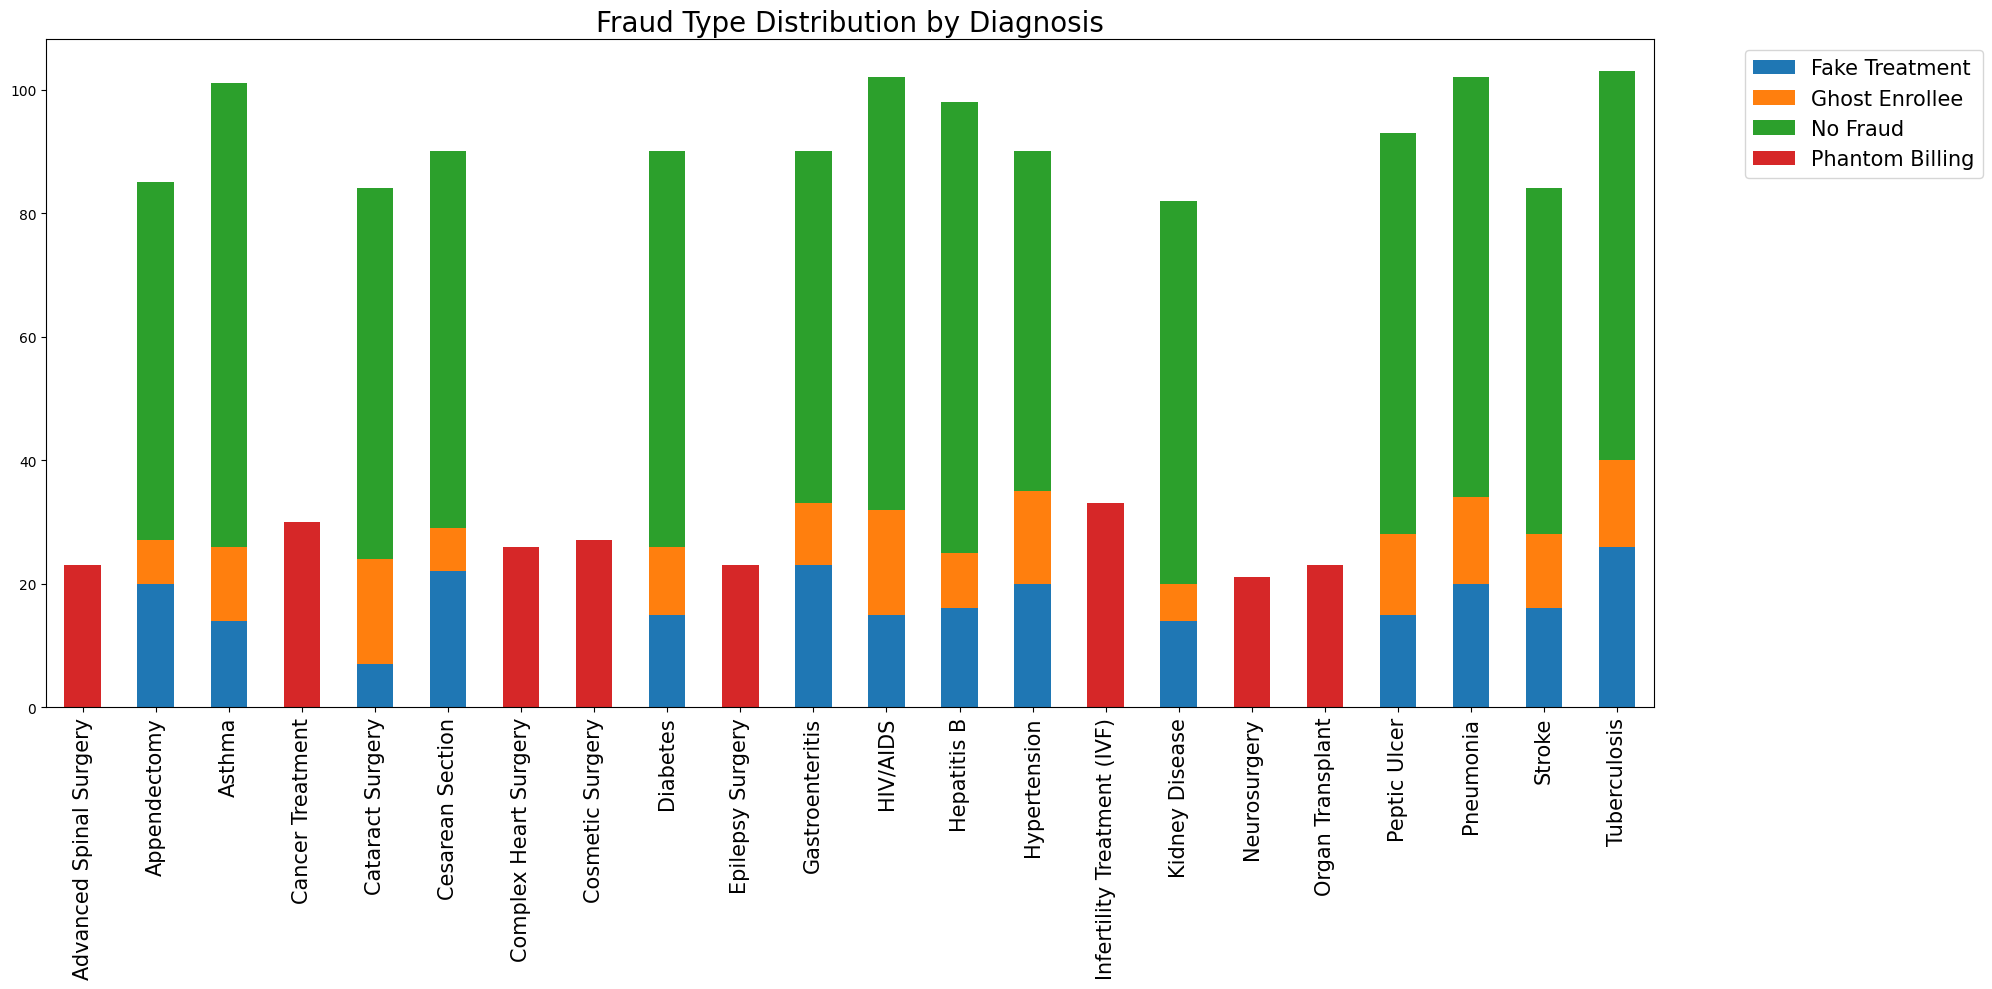

In [23]:
#Fraud Type Distribution by Diagnosis
plt.figure(figsize=(10,6))
fraud_diag.plot(kind="bar", stacked=True, figsize=(20,10))

plt.title("Fraud Type Distribution by Diagnosis", fontsize = 20)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=90, fontsize = 15)
plt.legend(title="", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize = 15)
plt.tight_layout()
plt.show()

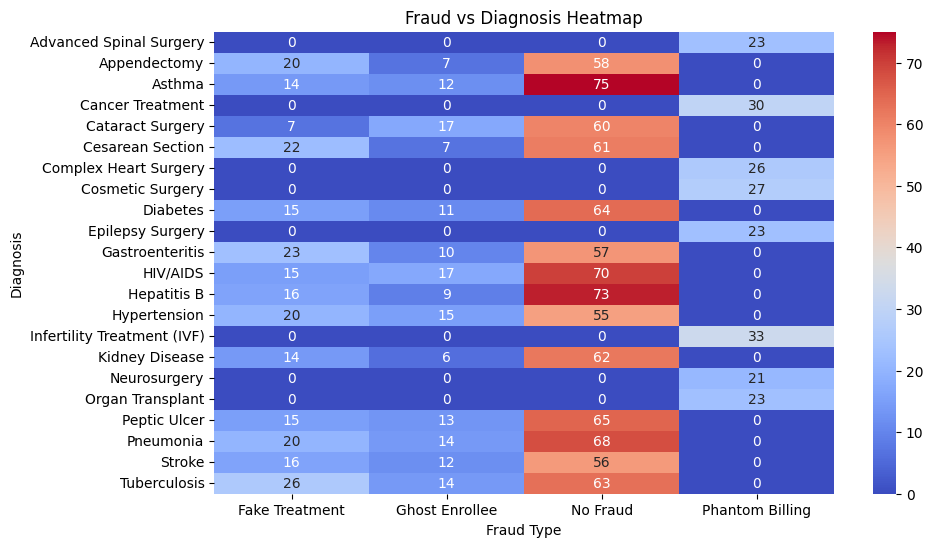

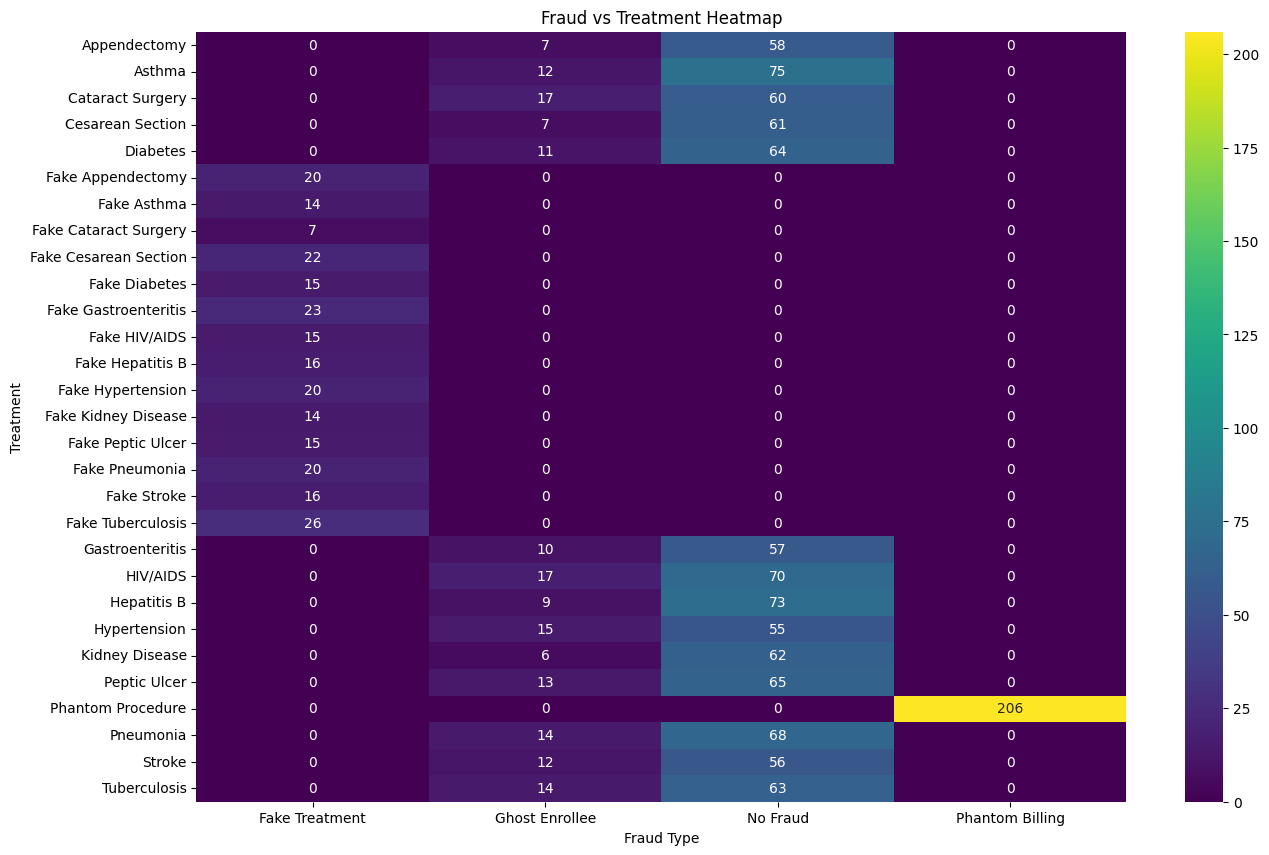

In [49]:
plt.figure(figsize=(15,10))
sns.heatmap(fraud_treat, annot=True, fmt="d", cmap="viridis")

plt.title("Fraud vs Treatment Heatmap")
plt.xlabel("Fraud Type")
plt.ylabel("Treatment")
plt.show()

### Fraud vs Diagnosis & Treatment Heatmaps

- Certain diagnoses like Tuberculosis, Hypertension, Gastroenteritis, and Pneumonia show fraud flags spread across multiple fraud types, indicating these are broad targets for various fraud schemes.
- High-cost specialty diagnoses (Epilepsy Surgery, Complex Heart Surgery, Cosmetic Surgery, Organ Transplant) show zero fraud flags as it is likely because they are too closely scrutinized clinically.
- Treatment-level heatmap mirrors diagnosis patterns — fraudulent treatments cluster around common, hard-to-verify procedures rather than complex surgical ones.

In [19]:
#Average Amount Billed by Fraud Type
df[["Amount Billed"] + ["Fraud Type"]].groupby("Fraud Type").mean()

,Amount Billed
Fraud Type,
Fake Treatment,381962.164074
Ghost Enrollee,262772.755366
No Fraud,257502.786257
Phantom Billing,544506.897573


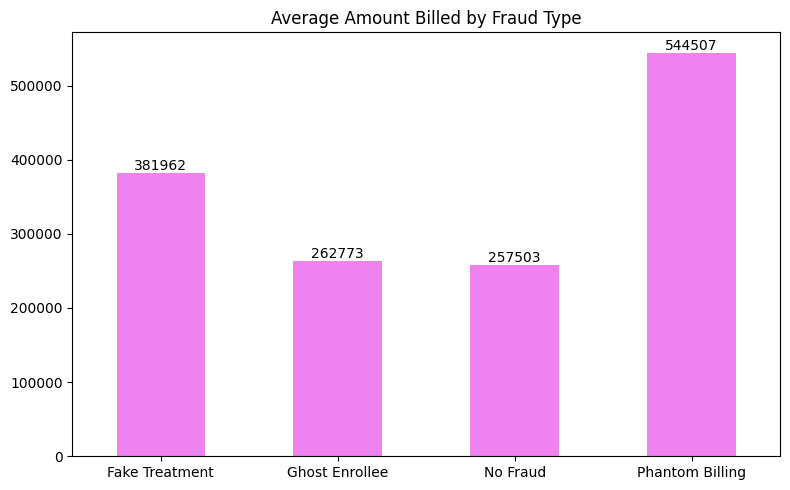

In [43]:
plt.figure(figsize=(8,5))
ax = fraud_cost.plot(kind="bar", color="violet")

plt.title("Average Amount Billed by Fraud Type")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)

for i, value in enumerate(fraud_cost):
    ax.text(i, value, f"{value:.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Fraud Type vs Amount Billed

- Phantom Billing has by far the highest average billed amount at 544,507 which is more than 2.1× the average legitimate claim (257,503).
- Fake Treatment averages 381,962, about 48% higher than legitimate claims.
- Ghost Enrollee (262,773) is closest to legitimate claim values, making it harder to detect through billing amount alone.
- Phantom Billing is clearly the most financially damaging fraud type per claim.

###### EDA completed